<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/29_stl_ewma_outlier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. 패키지와 원자료 (원본 324개월 자료 그대로 유지)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from statsmodels.tsa.seasonal import STL

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'font.size': 11})

raw_data = """
Date,Total
1986-01-01,9034
1986-02-01,9596
1986-03-01,10558
1986-04-01,9002
1986-05-01,9239
1986-06-01,8951
1986-07-01,9668
1986-08-01,10188
1986-09-01,9896
1986-10-01,10649
1986-11-01,8917
1986-12-01,8196
1987-01-01,10768
1987-02-01,12220
1987-03-01,14463
1987-04-01,12944
1987-05-01,11001
1987-06-01,11000
1987-07-01,11876
1987-08-01,13021
1987-09-01,13494
1987-10-01,14041
1987-11-01,11312
1987-12-01,10362
1988-01-01,12533
1988-02-01,14343
1988-03-01,14676
1988-04-01,12253
1988-05-01,11840
1988-06-01,12018
1988-07-01,11819
1988-08-01,12453
1988-09-01,12309
1988-10-01,13005
1988-11-01,11815
1988-12-01,10496
1989-01-01,13996
1989-02-01,15158
1989-03-01,15587
1989-04-01,14615
1989-05-01,14792
1989-06-01,14373
1989-07-01,14573
1989-08-01,14385
1989-09-01,15607
1989-10-01,15978
1989-11-01,14436
1989-12-01,12794
1990-01-01,15771
1990-02-01,16476
1990-03-01,16420
1990-04-01,15444
1990-05-01,16118
1990-06-01,15158
1990-07-01,15214
1990-08-01,16257
1990-09-01,15287
1990-10-01,15212
1990-11-01,13488
1990-12-01,12300
1991-01-01,15794
1991-02-01,17113
1991-03-01,17536
1991-04-01,15914
1991-05-01,16716
1991-06-01,15983
1991-07-01,16878
1991-08-01,17893
1991-09-01,16697
1991-10-01,18546
1991-11-01,15486
1991-12-01,15253
1992-01-01,18698
1992-02-01,	21100
1992-03-01,	22425
1992-04-01,	19923
1992-05-01,19454
1992-06-01,	18874
1992-07-01,	19676
1992-08-01,	19559
1992-09-01,	19500
1992-10-01,	19615
1992-11-01,	16814
1992-12-01,	15698
1993-01-01,	20273
1993-02-01,	20774
1993-03-01,	21309
1993-04-01,	19377
1993-05-01,	19211
1993-06-01,	19103
1993-07-01,	20086
1993-08-01,	19758
1993-09-01,	19162
1993-10-01,	19371
1993-11-01,	17709
1993-12-01,	17342
1994-01-01,	18772
1994-02-01,	19363
1994-03-01,	20001
1994-04-01,17112
1994-05-01,	18027
1994-06-01,	17173
1994-07-01,	18024
1994-08-01,	18983
1994-09-01,	17983
1994-10-01,	19151
1994-11-01,	16427
1994-12-01,	15461
1995-01-01,	19191
1995-02-01,	20008
1995-03-01,	21702
1995-04-01,	18649
1995-05-01,	19169
1995-06-01,	18631
1995-07-01,	18157
1995-08-01,	20187
1995-09-01,	18660
1995-10-01,	19920
1995-11-01,	16680
1995-12-01,	16018
1996-01-01,	20322
1996-02-01,	20613
1996-03-01,	22704
1996-04-01,	20276
1996-05-01,	20669
1996-06-01,	18074
1996-07-01,	18719
1996-08-01,	20217
1996-09-01,	19642
1996-10-01,	20842
1996-11-01,	18204
1996-12-01,	16898
1997-01-01,	20746
1997-02-01,	23058
1997-03-01,	24624
1997-04-01,	22154
1997-05-01,	22444
1997-06-01,	21471
1997-07-01,	21866
1997-08-01,	22548
1997-09-01,	21518
1997-10-01,	23408
1997-11-01,	19645
1997-12-01,	18278
1998-01-01,	23576
1998-02-01,	26650
1998-03-01,	26207
1998-04-01,	23195
1998-05-01,	22960
1998-06-01,	23002
1998-07-01,	22973
1998-08-01,	24089
1998-09-01,	22805
1998-10-01,	23241
1998-11-01,	21581
1998-12-01,	21119
1999-01-01,	23107
1999-02-01,	25780
1999-03-01,	28544
1999-04-01,	23488
1999-05-01,	23964
1999-06-01,	23720
1999-07-01,	25069
1999-08-01,	24618
1999-09-01,	24430
1999-10-01,	25229
1999-11-01,	22344
1999-12-01,	22372
2000-01-01,	25412
2000-02-01,	25354
2000-03-01,	29161
2000-04-01,	24924
2000-05-01,	24763
2000-06-01,	25342
2000-07-01,	24911
2000-08-01,	25847
2000-09-01,	23743
2000-10-01,	25036
2000-11-01,	21911
2000-12-01,	20752
2001-01-01,	24507
2001-02-01,	25968
2001-03-01,	28752
2001-04-01,	25167
2001-05-01,	24728
2001-06-01,	23690
2001-07-01,	24816
2001-08-01,	26004
2001-09-01,	24210
2001-10-01,	25083
2001-11-01,	21807
2001-12-01,	21635
2002-01-01,	27173
2002-02-01,	29308
2002-03-01,	28645
2002-04-01,	25023
2002-05-01,	27261
2002-06-01,	24670
2002-07-01,	26441
2002-08-01,	27961
2002-09-01,	26498
2002-10-01,	27800
2002-11-01,	23939
2002-12-01,	22930
2003-01-01,	27584
2003-02-01,	27586
2003-03-01,	30485
2003-04-01,	26135
2003-05-01,	27370
2003-06-01,	25487
2003-07-01,	26427
2003-08-01,	27672
2003-09-01,	26853
2003-10-01,	27875
2003-11-01,	23416
2003-12-01,	22482
2004-01-01,	27140
2004-02-01,	28526
2004-03-01,	28845
2004-04-01,	25033
2004-05-01,	24764
2004-06-01,	24896
2004-07-01,	24623
2004-08-01,	26538
2004-09-01,	24674
2004-10-01,	25863
2004-11-01,	23156
2004-12-01,	22721
2005-01-01,	26204
2005-02-01,	26526
2005-03-01,	27473
2005-04-01,	24536
2005-05-01,	25764
2005-06-01,	25154
2005-07-01,	23729
2005-08-01,	25336
2005-09-01,	24649
2005-10-01,	25904
2005-11-01,	22868
2005-12-01,	21825
2006-01-01,	26955
2006-02-01,	27349
2006-03-01,	29367
2006-04-01,	24071
2006-05-01,	23173
2006-06-01,	21740
2006-07-01,	22056
2006-08-01,	23923
2006-09-01,	22189
2006-10-01,	22458
2006-11-01,	19476
2006-12-01,	21056
2007-01-01,	22842
2007-02-01,	22943
2007-03-01,	23445
2007-04-01,	19176
2007-05-01,	22058
2007-06-01,	19451
2007-07-01,	20378
2007-08-01,	21778
2007-09-01,	20431
2007-10-01,	22486
2007-11-01,	18889
2007-12-01,	18574
2008-01-01,	24658
2008-02-01,	24997
2008-03-01,	23987
2008-04-01,	21199
2008-05-01,	21205
2008-06-01,	21553
2008-07-01,	21166
2008-08-01, 20720
2008-09-01,	18067
2008-10-01,	21121
2008-11-01,	16617
2008-12-01,	15917
2009-01-01,	19262
2009-02-01,	20658
2009-03-01,	22660
2009-04-01,	20147
2009-05-01,	18818
2009-06-01,	19017
2009-07-01,	19451
2009-08-01,	18502
2009-09-01,	18893
2009-10-01,	19480
2009-11-01,	15743
2009-12-01,	16554
2010-01-01,	19465
2010-02-01,	22617
2010-03-01,	22438
2010-04-01,	18511
2010-05-01,	19142
2010-06-01,	19063
2010-07-01,	18006
2010-08-01,	20386
2010-09-01,	20280
2010-10-01,	18894
2010-11-01,	15941
2010-12-01,	16851
2011-01-01,	18204
2011-02-01,	15564
2011-03-01,	17984
2011-04-01,	13979
2011-05-01,	12591
2011-06-01,	12408
2011-07-01,	12779
2011-08-01,	14233
2011-09-01,	13410
2011-10-01,	12893
2011-11-01,	11843
2011-12-01,	11321
2012-01-01,	13427
2012-02-01,	14447
2012-03-01,	14717
2012-04-01,	11998
2012-05-01,	13379
2012-06-01,	12463
2012-07-01,	13276
2012-08-01,	14442
2012-09-01,	13422
2012-10-01,	13795
2012-11-01,	13352
2012-12-01,	12716
"""

# 원자료의 숫자 앞뒤 공백/탭은 pandas가 자동 파싱합니다.


## A. 적응형 EWMA 잔차 경계 (탐색적 방법)

**내용 설명**: 과거 잔차의 EWMA로 다음 달의 기준 수준을 만들고, **이전 12개월**의 잔차 표준편차로 탐색적 상·하한을 설정합니다. 당월 값을 경계 추정에 넣지 않도록 `shift(1)`을 사용합니다.

- EWMA 중심: 직전까지 관측된 잔차에 기초한 예측 수준
- 경계: 직전 EWMA 중심 ± 3 × 이전 12개월 표준편차
- 판정 대상: 해당 월의 **잔차**

이 방식은 관측 조건에 따라 경계가 변하는 **휴리스틱(heuristic) 탐지 방법**입니다. 표준적인 EWMA 공정관리도와 동일하지 않으며, ±3배에 대한 고정된 오경보율도 보장하지 않습니다.

Observations: 324; Method A signals: 18 (eligible months: 312)
            Total  Residual  EWMA_prev      LCL      UCL  Anomaly
Date                                                             
1987-03-01  14463   1241.39     -51.82  -785.59   681.96     True
1987-04-01  12944   1474.62     147.14 -1124.21  1418.49     True
1992-02-01  21100   1254.03     -21.67  -981.22   937.89     True
1992-03-01  22425   2190.26     174.59 -1307.86  1657.04     True
1993-11-01  17709   1166.44     178.81  -766.62  1124.24     True
1993-12-01  17342   2040.28     330.75  -889.27  1550.78     True
1996-06-01  18074  -1229.73      94.94  -841.66  1031.55     True
1998-02-01  26650   2325.87      43.35 -1244.73  1331.43     True
2002-01-01  27173   1100.09    -143.08 -1281.37   995.21     True
2002-02-01  29308   2686.32      48.18 -1373.15  1469.51     True
2004-02-01  28526   1168.76      51.97  -993.52  1097.45     True
2004-05-01  24764  -1490.06     135.52 -1181.01  1452.05     True
2005-06-01  2

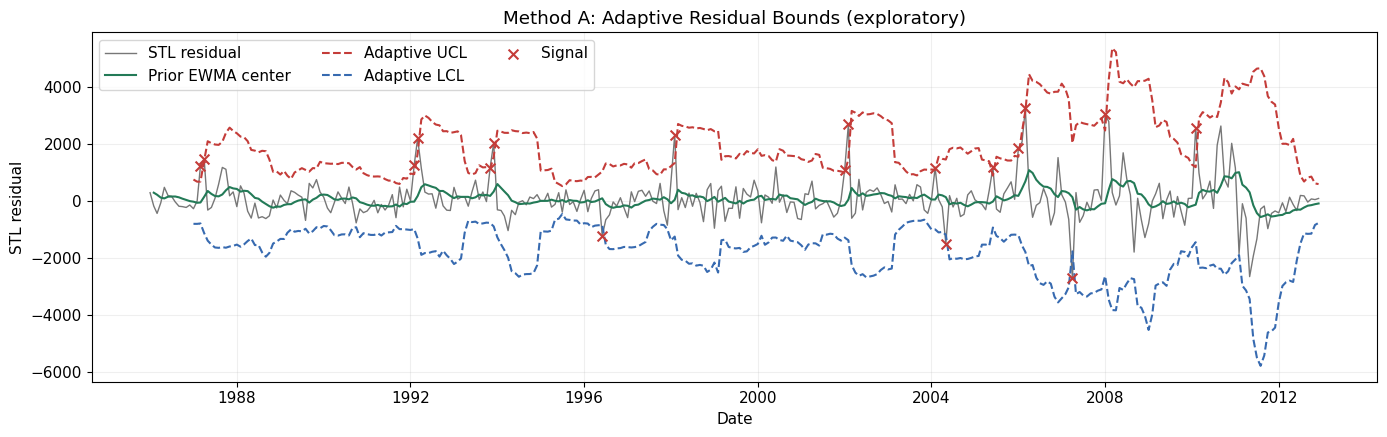

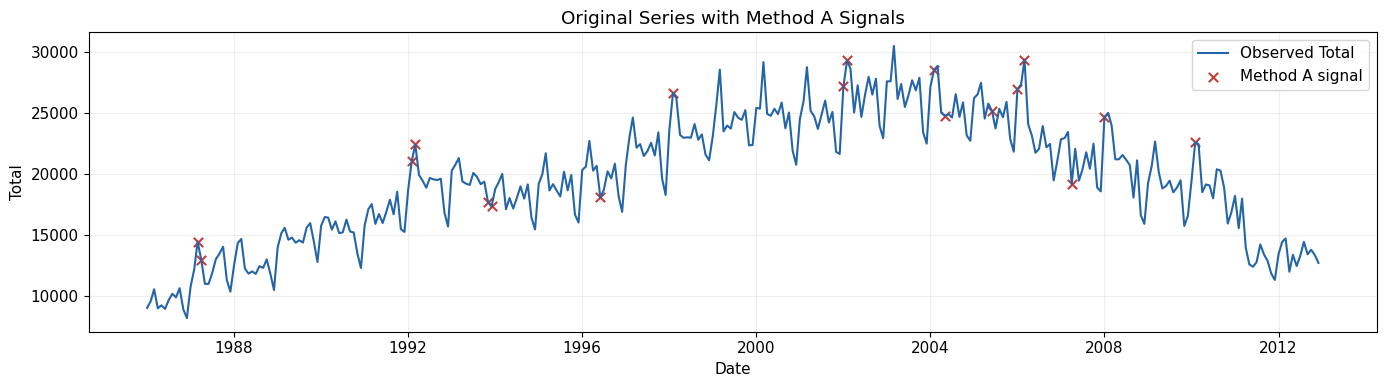

In [2]:
# 2. 공통 데이터 적재 및 실제 STL 분해
df = pd.read_csv(StringIO(raw_data), skipinitialspace=True)
df['Date'] = pd.to_datetime(df['Date'], errors='raise')
df['Total'] = pd.to_numeric(df['Total'], errors='raise')
df = df.set_index('Date').sort_index()
if df.index.has_duplicates:
    raise ValueError('중복된 월 날짜가 있습니다.')
expected = pd.date_range(df.index.min(), df.index.max(), freq='MS')
if not df.index.equals(expected) or df['Total'].isna().any():
    raise ValueError('월별 날짜 간격 또는 수치 데이터에 누락이 있습니다.')

# STL은 seasonal_decompose와 다른 반복적 국소평활 분해 방법입니다.
stl_result = STL(df['Total'], period=12, robust=True).fit()
resid = stl_result.resid.rename('Residual')

# 3. 방법 A: 과거 정보만으로 계산한 탐색적 적응형 경계
span = 12
prior_mean = resid.ewm(span=span, adjust=False).mean().shift(1)
prior_std = resid.rolling(window=span, min_periods=span).std(ddof=1).shift(1)
a_ucl = prior_mean + 3 * prior_std
a_lcl = prior_mean - 3 * prior_std
a_signal = ((resid > a_ucl) | (resid < a_lcl)) & a_ucl.notna()

a_results = pd.DataFrame({'Total':df['Total'], 'Residual':resid,
                          'EWMA_prev':prior_mean, 'LCL':a_lcl, 'UCL':a_ucl,
                          'Anomaly':a_signal})
print(f'Observations: {len(df)}; Method A signals: {int(a_signal.sum())} '
      f'(eligible months: {int(a_ucl.notna().sum())})')
print(a_results.loc[a_signal].round(2).to_string() if a_signal.any() else 'No Method A signals')

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(resid.index, resid, color='#777777', linewidth=1, label='STL residual')
ax.plot(prior_mean.index, prior_mean, color='#237a57', label='Prior EWMA center')
ax.plot(a_ucl.index, a_ucl, '--', color='#c43c39', label='Adaptive UCL')
ax.plot(a_lcl.index, a_lcl, '--', color='#376ab0', label='Adaptive LCL')
ax.scatter(resid.index[a_signal], resid[a_signal], color='#c43c39', marker='x', s=50, label='Signal', zorder=4)
ax.set(title='Method A: Adaptive Residual Bounds (exploratory)', xlabel='Date', ylabel='STL residual')
ax.grid(alpha=.2); ax.legend(ncol=3); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['Total'], label='Observed Total', color='#2465a7')
ax.scatter(df.index[a_signal], df.loc[a_signal,'Total'], color='#c43c39', marker='x', s=45, label='Method A signal')
ax.set(title='Original Series with Method A Signals', xlabel='Date', ylabel='Total')
ax.grid(alpha=.2); ax.legend(); plt.tight_layout(); plt.show()

## B. 이론적 EWMA 관리도 (통계량 자체를 판정)\n\n**내용 설명**: 잔차 $e_t$에 대해 EWMA 관리통계량 $z_t$를 계산하고, **잔차가 아니라 $z_t$가 관리한계를 벗어나는지** 판정합니다.\n\n$$\nz_t=\lambda e_t+(1-\lambda)z_{t-1}\n$$\n\n초기 중심 $z_0=\mu_0$이며, 서로 독립적이고 분산이 일정한 잔차를 가정하면 시점별 한계는 다음과 같습니다.\n\n$$\n\mathrm{UCL}_t=\mu_0+L\sigma_0\sqrt{\frac{\lambda}{2-\lambda}\left(1-(1-\lambda)^{2t}\right)}\n$$\n\n$$\n\mathrm{LCL}_t=\mu_0-L\sigma_0\sqrt{\frac{\lambda}{2-\lambda}\left(1-(1-\lambda)^{2t}\right)}\n$$\n\n여기서는 학습용 기준구간의 잔차로 $\mu_0,\sigma_0$를 추정합니다. $\lambda=0.2$를 사용하여 완만한 변화에도 반응하도록 설정하고, $L=3$을 예시로 사용합니다. **기준구간은 한계 추정에 사용되었으므로, 이후 구간의 경보를 독립적인 외표본 성능으로 해석할 수 없습니다.** (STL은 전체 자료로 적합되었기 때문입니다.)\n\n**주의**: STL 잔차에 자기상관·이분산·비정규성이 있으면 이론적 관리한계의 오경보 특성이 달라집니다. 본 실습은 학습용 시각화이지 검증된 실시간 공정관리 체계가 아닙니다.

Reference window: 60 months; monitoring months: 264
Method B EWMA signals: 38
            Total  Residual   EWMA_z     LCL     UCL  Signal
Date                                                        
1992-03-01  22425   2190.26   641.49 -417.16  533.25    True
1992-04-01  19923   1148.46   742.88 -417.16  533.25    True
1992-05-01  19454    311.70   656.65 -417.16  533.25    True
1992-06-01  18874    242.75   573.87 -417.16  533.25    True
1993-12-01  17342   2040.28   707.59 -417.16  533.25    True
2002-02-01  29308   2686.32   605.58 -417.16  533.25    True
2006-01-01  26955   1845.24   538.96 -417.16  533.25    True
2006-02-01  27349   2062.57   843.68 -417.16  533.25    True
2006-03-01  29367   3242.65  1323.48 -417.16  533.25    True
2006-04-01  24071    444.50  1147.68 -417.16  533.25    True
2006-05-01  23173   -569.97   804.15 -417.16  533.25    True
2006-06-01  21740   -150.48   613.22 -417.16  533.25    True
2007-04-01  19176  -2698.78  -487.65 -417.16  533.25    True
2007-07

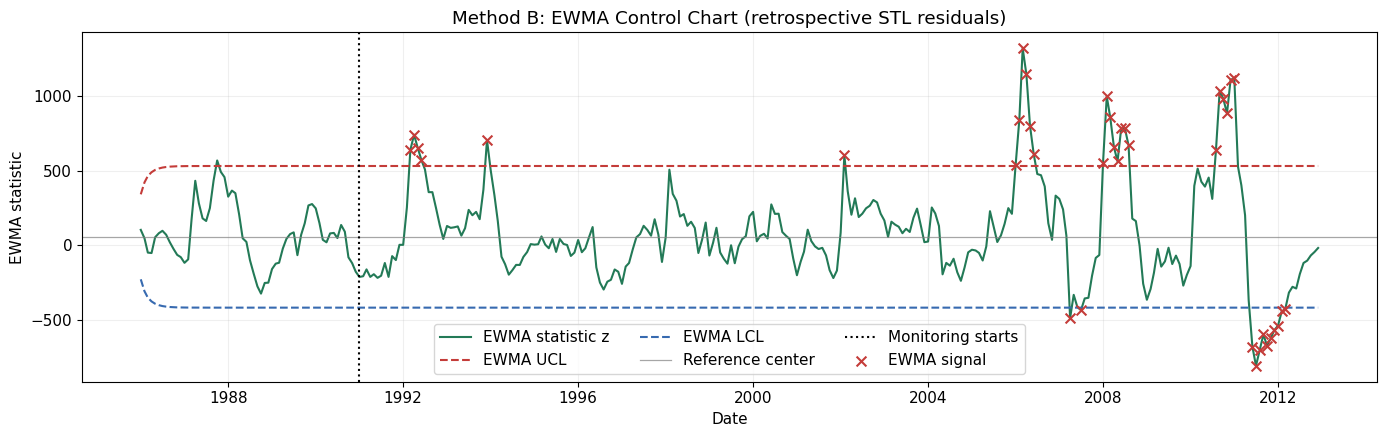

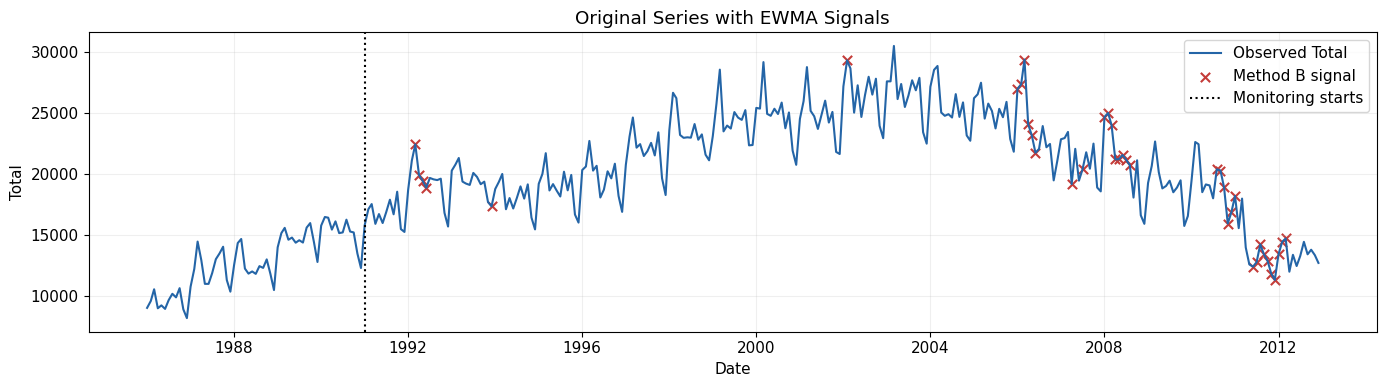

                     Method  Signals
A: Adaptive residual bounds       18
          B: EWMA statistic       38


In [3]:
# 4. 방법 B: EWMA 관리통계량과 이론적 시변 관리한계
# 기준구간(reference)을 먼저 정하고, 그 구간의 잔차로 중심·표준편차를 추정합니다.
reference_months = 60
if len(resid) <= reference_months:
    raise ValueError('기준구간 이후에 분석할 데이터가 부족합니다.')
mu0 = float(resid.iloc[:reference_months].mean())
sigma0 = float(resid.iloc[:reference_months].std(ddof=1))
if not np.isfinite(sigma0) or sigma0 <= 0:
    raise ValueError('기준구간의 잔차 표준편차를 확인하세요.')

lam = 0.2  # smoothing parameter: 0 < lam <= 1 (원본의 0.9는 아래 EWMA span=12와 불일치)
L = 3.0    # control limit multiplier; 보편적인 정확도 보증값은 아닙니다.

# z_0 = mu0 기준으로 순차적 EWMA 업데이트.
z = np.empty(len(resid), dtype=float)
prev = mu0
for i, e in enumerate(resid.to_numpy()):
    prev = lam * e + (1 - lam) * prev
    z[i] = prev
ewma_stat = pd.Series(z, index=resid.index, name='EWMA_z')

# 독립·동분산 잔차 가정하의 유한시점 분산 보정: 첫 월은 t=1.
t = np.arange(1, len(resid)+1)
limit_width = L * sigma0 * np.sqrt(lam / (2-lam) * (1-(1-lam)**(2*t)))
b_ucl = pd.Series(mu0 + limit_width, index=resid.index, name='UCL')
b_lcl = pd.Series(mu0 - limit_width, index=resid.index, name='LCL')
# 기준구간 이후부터 관리신호를 집계합니다.
monitor = pd.Series(np.arange(len(resid)) >= reference_months, index=resid.index)
b_signal = ((ewma_stat > b_ucl) | (ewma_stat < b_lcl)) & monitor

b_results = pd.DataFrame({'Total':df['Total'], 'Residual':resid, 'EWMA_z':ewma_stat,
                          'LCL':b_lcl, 'UCL':b_ucl, 'Signal':b_signal})
print(f'Reference window: {reference_months} months; monitoring months: {int(monitor.sum())}')
print(f'Method B EWMA signals: {int(b_signal.sum())}')
print(b_results.loc[b_signal].round(2).to_string() if b_signal.any() else 'No Method B signals')

# 차트 1: EWMA 관리통계량 z_t가 한계를 넘는지 보여줍니다.
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(ewma_stat.index, ewma_stat, color='#237a57', linewidth=1.5, label='EWMA statistic z')
ax.plot(b_ucl.index, b_ucl, '--', color='#c43c39', label='EWMA UCL')
ax.plot(b_lcl.index, b_lcl, '--', color='#376ab0', label='EWMA LCL')
ax.axhline(mu0, color='gray', alpha=.7, linewidth=.9, label='Reference center')
ax.axvline(resid.index[reference_months], color='black', linestyle=':', label='Monitoring starts')
ax.scatter(ewma_stat.index[b_signal], ewma_stat[b_signal], color='#c43c39', marker='x', s=50, label='EWMA signal', zorder=5)
ax.set(title='Method B: EWMA Control Chart (retrospective STL residuals)', xlabel='Date', ylabel='EWMA statistic')
ax.grid(alpha=.2); ax.legend(ncol=3); plt.tight_layout(); plt.show()

# 차트 2: 방법 B의 신호가 나타난 시점의 원계열을 강조합니다.
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['Total'], color='#2465a7', label='Observed Total')
ax.scatter(df.index[b_signal], df.loc[b_signal,'Total'], color='#c43c39', marker='x', s=45, label='Method B signal')
ax.axvline(resid.index[reference_months], color='black', linestyle=':', label='Monitoring starts')
ax.set(title='Original Series with EWMA Signals', xlabel='Date', ylabel='Total')
ax.grid(alpha=.2); ax.legend(); plt.tight_layout(); plt.show()

# 간단 비교: 두 방식은 감시 통계량이 다르므로 검출 개수가 같을 필요가 없습니다.
print(pd.DataFrame({'Method':['A: Adaptive residual bounds','B: EWMA statistic'],
                    'Signals':[int(a_signal.sum()), int(b_signal.sum())]}).to_string(index=False))